# Sudan Climate EDA

## 1. Data Loading & Date Parsing

In this section, we load the Sudan climate dataset, add a country identifier, and convert the YEAR and DOY (Day of Year) columns into a proper datetime format for time-based analysis.

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/sudan.csv")

# Add country column
df["Country"] = "Sudan"

# Convert YEAR and DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

# Preview data
df.head()

# Check data types and structure
# df.info()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## 2. Summary Statistics & Missing-Value Report

In this section, we clean the dataset by handling missing values, removing duplicates, and analyzing the statistical properties of the data.

In [20]:
df.replace(-999, np.nan, inplace=True)

### Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data.  
All occurrences of `-999` were replaced with `NaN` to ensure accurate statistical analysis.

In [37]:
duplicates = df.duplicated().sum()
duplicates

0

In [53]:
df = df.drop_duplicates()

### Duplicate Records

No duplicate rows were found in the dataset (0 duplicates).

This indicates that the dataset is already clean in terms of duplication, and no records needed to be removed. Ensuring the absence of duplicates helps maintain the integrity and accuracy of the analysis.

In [82]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains 4,108 records with no missing values across all variables, indicating a clean and complete dataset.

The average temperature (T2M ≈ 28.76°C) suggests a consistently warm climate. Temperature variability is moderate, with a standard deviation of about 4.68°C. The daily temperature range (T2M_RANGE ≈ 15.27°C) is relatively large, showing significant differences between daytime highs and nighttime lows.

Rainfall (PRECTOTCORR) is highly skewed and variable. The median is 0 mm, meaning most days have no rainfall, while the maximum reaches 66.49 mm, indicating occasional heavy rain events.

Humidity (RH2M ≈ 31.36%) is relatively low on average, suggesting generally dry conditions rather than humid ones. Wind speed (WS2M ≈ 3.48 m/s) is fairly stable with low variation.

Overall, the data reflects a warm climate with dry conditions most of the time, interrupted by occasional intense rainfall events, indicating a seasonal rainfall pattern rather than consistently humid weather.

In [96]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [109]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


### Missing Value Analysis

The dataset contains no missing values across all columns (0% missing). Additionally, no columns exceed the 5% missing value threshold.

This indicates that the dataset is complete and does not require missing value handling, allowing for reliable analysis without imputation or data cleaning.

## 3. Outlier Detection & Basic Cleaning

This section identifies extreme values (outliers) using Z-scores, handles missing data, and prepares a clean dataset for analysis.

In [132]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)

outlier_rows = outliers.any(axis=1).sum()

outlier_rows

84

### Outlier Detection

Outliers were identified using the Z-score method.  
Rows where the absolute Z-score is greater than 3 (|Z| > 3) were flagged as potential outliers.

A total of **84 rows** were identified as containing outliers, indicating the presence of extreme values in some variables such as temperature, rainfall, or wind speed.

### Outlier Handling Decision

Outliers were detected in 84 rows using the Z-score method (|Z| > 3). However, these values are not necessarily errors, especially for variables like rainfall (PRECTOTCORR), where extreme values can represent real-world heavy precipitation events.

Therefore, the outliers will be **retained** rather than removed or capped. Dropping them could lead to loss of important information, and capping may distort genuine extreme patterns.

Keeping the outliers ensures that the dataset preserves natural variability, which is important for accurate climate analysis.

In [141]:

threshold = int(0.7 * len(df.columns))
df = df.dropna(thresh=threshold)

df[cols] = df[cols].ffill()

### Missing Value Handling

Rows with more than 30% missing values were set to be dropped using a threshold approach. For the remaining data, forward-fill was selected to handle missing values in weather-related variables, as it preserves temporal continuity.

However, after analysis, no missing values were found in the dataset. Therefore, no rows were dropped and no imputation was required. The dataset remains complete and ready for analysis.

In [160]:
df.to_csv("../data/sudan_clean.csv", index=False)

### Data Export

The cleaned dataset was exported to `data/sudan_clean.csv`.

## 4. Time Series Analysis

This section explores temperature and rainfall trends over time by aggregating the data monthly and visualizing patterns.

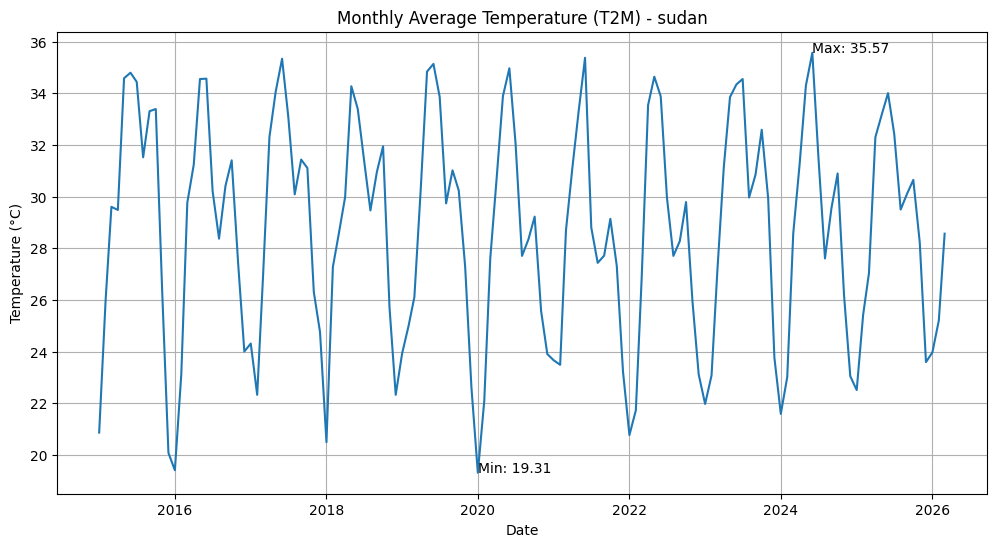

In [169]:
# Monthly average temperature (T2M)
import matplotlib.pyplot as plt


monthly_temp = df.groupby([df["Date"].dt.to_period("M")])["T2M"].mean()

monthly_temp.index = monthly_temp.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_temp.index, monthly_temp.values)

plt.title("Monthly Average Temperature (T2M) - sudan")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

max_temp = monthly_temp.max()
min_temp = monthly_temp.min()

max_date = monthly_temp.idxmax()
min_date = monthly_temp.idxmin()

plt.annotate(f"Max: {max_temp:.2f}", (max_date, max_temp))
plt.annotate(f"Min: {min_temp:.2f}", (min_date, min_temp))

plt.show()

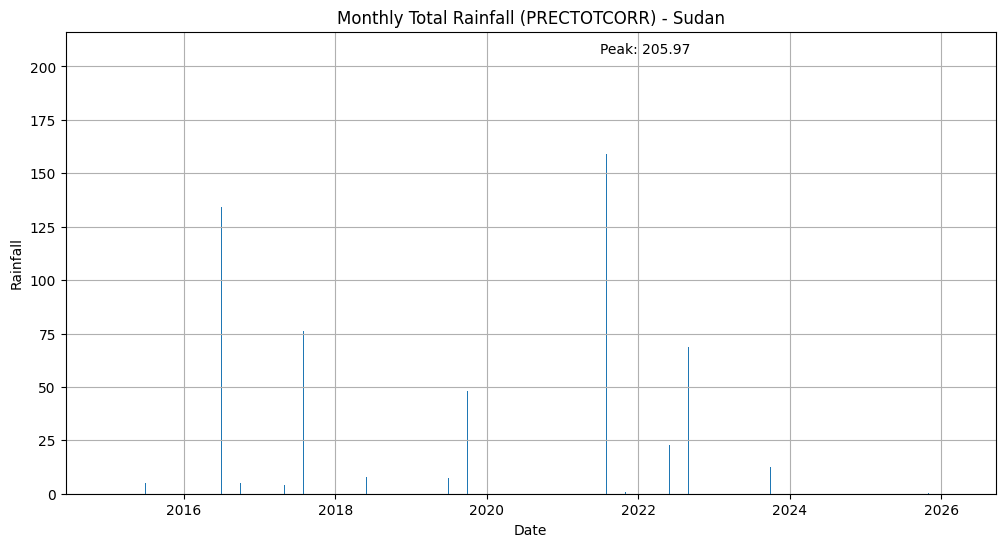

In [177]:
# Monthly total rainfall
monthly_rain = df.groupby([df["Date"].dt.to_period("M")])["PRECTOTCORR"].sum()
monthly_rain.index = monthly_rain.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Monthly Total Rainfall (PRECTOTCORR) - Sudan")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.grid()

max_rain = monthly_rain.max()
max_rain_date = monthly_rain.idxmax()


plt.annotate(f"Peak: {max_rain:.2f}", (max_rain_date, max_rain))

plt.show()

### Interpretation

- The temperature trend shows **clear and consistent seasonal cycles**, typical of Sudan’s hot semi-arid to arid climate. There is no strong long-term increasing or decreasing trend, but rather regular yearly fluctuations.

- The **highest temperature** is observed around **2024**, reaching approximately **35.57°C**, indicating extremely hot seasonal conditions.

- The **lowest temperature** occurs around **early 2020**, dropping to about **19.31°C**, reflecting cooler periods within the yearly cycle.

- Rainfall exhibits **high variability and strong seasonality**, occurring in short, concentrated periods rather than being evenly distributed.

- The **peak rainfall (~205.97 mm)** occurs around **2021–2022**, suggesting a short but intense rainy season.

- Most months record **very low or near-zero rainfall**, highlighting **extended dry seasons** typical of Sudan’s climate.

### Overall Insight

The data reflects a **consistently hot climate with pronounced seasonal temperature patterns and irregular rainfall distribution**. Sudan experiences **long dry periods interrupted by brief, intense rainy seasons**, characteristic of a **semi-arid climate**.

## 5. Correlation & Relationship Analysis

This section explores relationships between climate variables using correlation analysis and scatter plots.

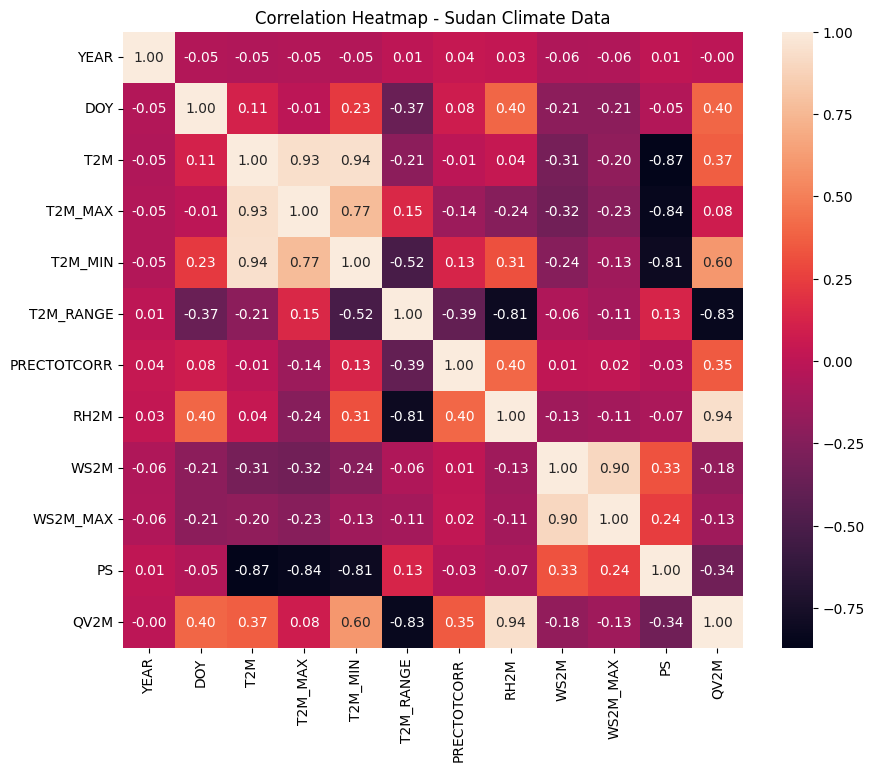

In [184]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=["float64", "int64"])


corr = numeric_df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap - Sudan Climate Data")
plt.show()

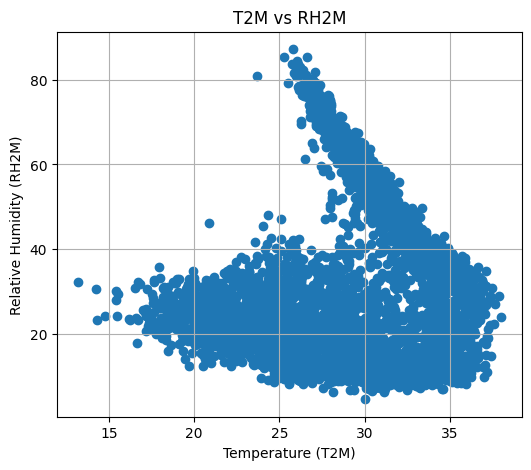

In [190]:
#Scatter Plot (T2M vs RH2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M")

plt.grid()
plt.show()

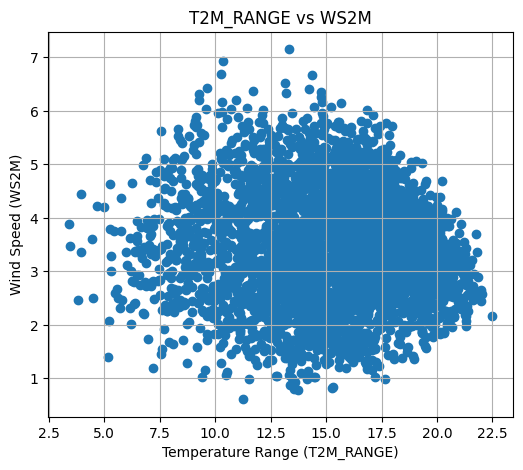

In [195]:
#Scatter Plot (T2M_RANGE vs WS2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])

plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.title("T2M_RANGE vs WS2M")

plt.grid()
plt.show()

### Correlation Interpretation

- There is a **very strong positive correlation** between **T2M and T2M_MIN (≈ 0.94)** and **T2M and T2M_MAX (≈ 0.93)**. This confirms that average temperature is highly dependent on both minimum and maximum temperatures.

- A **strong negative correlation** exists between **T2M and surface pressure (PS) (≈ -0.87)**, indicating that higher temperatures are associated with lower atmospheric pressure.

- A **very strong positive correlation** is observed between **WS2M and WS2M_MAX (≈ 0.90)**, showing that average wind speed closely follows maximum wind speed patterns.

- A **strong negative correlation** exists between **T2M_RANGE and RH2M (≈ -0.81)**, suggesting that larger temperature variations are associated with lower humidity levels.

- **Specific humidity (QV2M)** shows a **strong positive correlation with RH2M (≈ 0.94)** and a **moderate positive relationship with temperature**, indicating that moisture in the air increases with humidity and somewhat with temperature.

### Scatter Plot Insights

- The **T2M vs RH2M plot** shows a **clear negative relationship**, where humidity decreases as temperature increases. The pattern is more pronounced than weak, especially at higher temperatures.

- The **T2M_RANGE vs WS2M plot** shows a **very weak or no clear relationship**, as the data points are widely scattered. This suggests that wind speed has little to no direct influence on temperature range.

### Overall Insight

Temperature-related variables are **highly interdependent**, while humidity and pressure show **strong but inverse relationships with temperature**. Wind speed, however, demonstrates **limited influence on temperature variation**, highlighting the complex and multi-factor nature of climate dynamics.

## 6. Distribution Analysis

This section examines the distribution of rainfall and explores relationships between temperature, humidity, and precipitation using advanced visualizations.

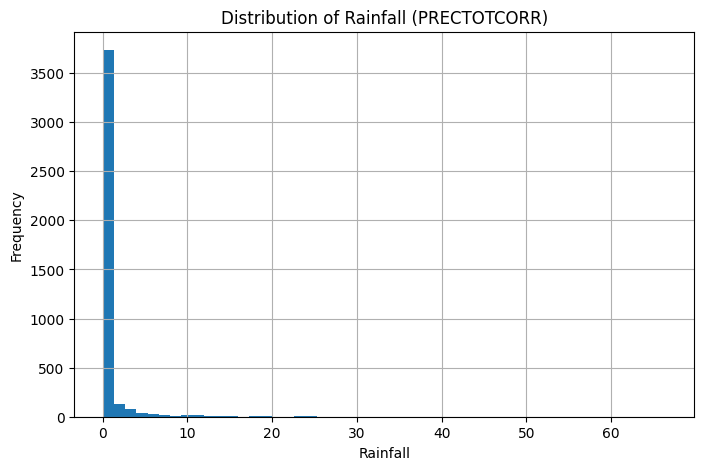

In [199]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.title("Distribution of Rainfall (PRECTOTCORR)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.grid()
plt.show()

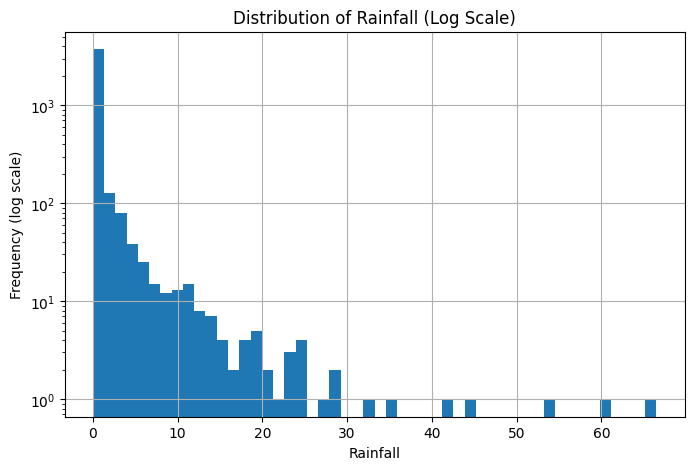

In [202]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")

plt.title("Distribution of Rainfall (Log Scale)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency (log scale)")

plt.grid()
plt.show()

### Rainfall Distribution Interpretation

- The rainfall distribution is **highly right-skewed**, with a very large concentration of values near **0 mm** and a long tail extending to higher rainfall values (up to ~65 mm).

- This indicates that **most days experience little to no rainfall**, while only a small number of days receive moderate to heavy precipitation.

- The presence of extreme values confirms **occasional intense rainfall events**, though these are relatively rare compared to dry days.

- When visualized on a **log scale**, the distribution becomes clearer, revealing the spread of **low to moderate rainfall values** that are otherwise compressed near zero in the standard scale.

- The rapid decline in frequency as rainfall increases highlights that **heavy rainfall events are infrequent but significant**.

### Overall Insight

The distribution reflects a **dry to semi-arid climate pattern**, where rainfall is **infrequent and unevenly distributed**, with long dry periods interrupted by **occasional short bursts of rainfall**, rather than a consistently wet tropical pattern.

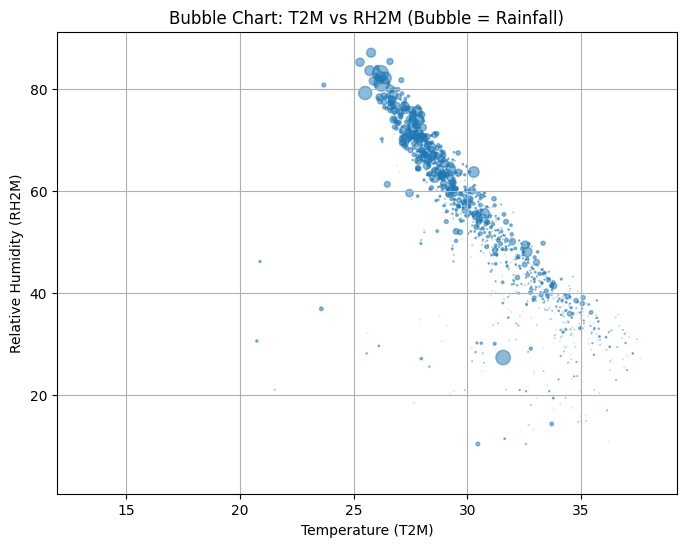

In [205]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 2,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Bubble Chart: T2M vs RH2M (Bubble = Rainfall)")

plt.grid()
plt.show()

### Bubble Chart Interpretation

- The bubble chart illustrates the relationship between **temperature (T2M)** and **relative humidity (RH2M)**, with **rainfall represented by bubble size**.

- There is a **clear negative relationship between temperature and humidity**, where humidity decreases as temperature increases. Most data points form a downward trend from high humidity–low temperature to low humidity–high temperature.

- The majority of observations are concentrated between **26°C to 32°C** and **40% to 80% humidity**, reflecting typical conditions in a **hot semi-arid climate**.

- **Larger bubbles (higher rainfall)** are mostly found in regions with **higher humidity (above ~60%) and moderate temperatures (~26–30°C)**, indicating that rainfall is more likely under these conditions.

- At **lower humidity levels (below ~40%)**, bubbles are generally very small or absent, confirming that **rainfall is minimal during dry conditions**.

- There is **no strong direct relationship between temperature and rainfall alone**, but rainfall clearly depends on **humidity levels**, with higher moisture supporting precipitation.

### Overall Insight

The visualization shows that **humidity is the primary driver of rainfall**, while temperature indirectly influences it through its inverse relationship with humidity. This pattern is consistent with a **semi-arid climate**, where rainfall occurs mainly during periods of relatively higher atmospheric moisture.

## References

- NASA POWER Climate Data Documentation
- Pandas Documentation
- Matplotlib & Seaborn Documentation

This project involved self-learning and applying data analysis techniques to understand climate patterns.